# Tripolar fold functionality: relative vorticity across the Arctic seam

Tripolar ocean grids (MOM6, NEMO, Oceananigans) cover the Arctic with a
**bipolar cap** whose northern edge **folds** onto itself. Relative vorticity

$$\zeta = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}$$

is the natural diagnostic that *exposes* the fold: the northernmost
$\partial u/\partial y$ reaches across the pole, and the fold both mirrors the
zonal axis and **flips the sign** of the folded velocity. Treating the grid as
merely zonally periodic ("naive") therefore gets the Arctic vorticity wrong
right at the seam.

This notebook computes $\zeta$ **two ways** — naive (X-periodic only) and
fold-aware — for **all three models**, and plots them on a **North-polar
projection** so the fold appears as a **line through the Arctic**. xgcm
expresses the fold as a single per-axis boundary,

```python
boundary={"X": "periodic", "Y": {"fold": <pivot>}}
```

with the pivot set by each model's grid generation: **MOM6** and **NEMO** use an
F-point (`"corner"`) pivot, **Oceananigans** uses `"u"`.

> **Dependencies** — the NEMO and MOM6 sections read CMIP6 from the Pangeo
> cloud (`pip install zarr gcsfs`).

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from xgcm import Grid

## The fold-aware vorticity, in one helper

`grid.diff(v, "X")` is unaffected by the fold (X is periodic), but
`grid.diff(u, "Y")` crosses the northern seam — so we pass it as a vector
component (`{"X": u}` with its `other_component`) on the fold grid, which mirrors
**and sign-flips** the folded halo. The naive version uses a plain fill at the
northern edge. A second helper draws the three fields on a North-polar
projection, cropped to the Arctic.

In [2]:
def naive_and_fold_vorticity(coords_ds, gridcoords, u, v, fold_pivot):
    '''Return (zeta_naive, zeta_fold) = dv/dx - du/dy, computed with an
    X-periodic-only grid and with the tripolar north fold, respectively.'''
    def make(y_boundary):
        return Grid(coords_ds, coords=gridcoords,
                    boundary={"X": "periodic", "Y": y_boundary},
                    autoparse_metadata=False)

    g_naive, g_fold = make("fill"), make({"fold": fold_pivot})
    dvdx = g_fold.diff(v, "X", boundary="fill")                 # X periodic -> fold irrelevant
    dudy_naive = g_naive.diff(u, "Y", boundary="fill", fill_value=0.0)
    dudy_fold = g_fold.diff({"X": u}, "Y", other_component={"Y": v}, boundary="fill")
    return dvdx - dudy_naive, dvdx - dudy_fold


def show_fold_effect(zeta_naive, zeta_fold, lon, lat, label, latmin=60):
    '''Plot naive / fold-aware vorticity and their difference on a North Polar
    Stereographic map, cropped to lat > latmin. The naive-minus-fold panel
    (on its own colour scale) lights up only along the fold seam — a line
    across the Arctic between the two grid poles.'''
    zN, zF = np.asarray(zeta_naive), np.asarray(zeta_fold)
    lon, lat = np.asarray(lon), np.asarray(lat)
    cap = np.nanmax(lat, axis=1) > (latmin - 5)    # crop to the northern cap
    sl = slice(int(np.argmax(cap)), None)
    zN, zF, lon, lat = zN[sl], zF[sl], lon[sl], lat[sl]
    diff = zN - zF

    lim = float(np.nanpercentile(np.abs(zF), 99)) or 1.0
    nz = np.abs(diff)[np.isfinite(diff) & (diff != 0)]
    dlim = float(np.nanpercentile(nz, 99)) if nz.size else lim

    proj = ccrs.NorthPolarStereo()
    pc = ccrs.PlateCarree()
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.8),
                             subplot_kw=dict(projection=proj))
    for ax, (field, title, vlim) in zip(
            axes, [(zN, "naive (X-periodic only)", lim), (zF, "fold-aware", lim),
                   (diff, "naive − fold", dlim)]):
        ax.set_extent([-180, 180, latmin, 90], pc)
        pm = ax.pcolormesh(lon, lat, field, transform=pc, shading="nearest",
                           cmap="RdBu_r", vmin=-vlim, vmax=vlim)
        ax.coastlines(linewidth=0.4, color="0.4")
        ax.gridlines(color="k", alpha=0.2, linewidth=0.3)
        ax.set_title(f"{label}: {title}", fontsize=10)
        fig.colorbar(pm, ax=ax, shrink=0.5, pad=0.06)
    plt.tight_layout()
    plt.show()

    seam = float(np.nanmax(np.abs(diff[-1])))
    below = float(np.nanmax(np.abs(diff[:-1])))
    print(f"{label}: max|naive - fold|  at seam = {seam:.4g};  below seam = {below:.4g}")

## Oceananigans (`TripolarGrid`, `"u"` pivot)

Surface velocities from a realistic **1° global ClimaOcean / Oceananigans**
simulation (ECCO-initialized, JRA55-forced; generated by
`scripts/run_one_degree_simulation.jl`). `u` sits on the X-face, `v` on the
Y-face; the vorticity lands on the NE corner (`lon_ff`/`lat_ff`), whose top row
needs the folded neighbour. Oceananigans pivots on **U-points** (`"u"`) — an
independent third convention from MOM6/NEMO's `"corner"`.

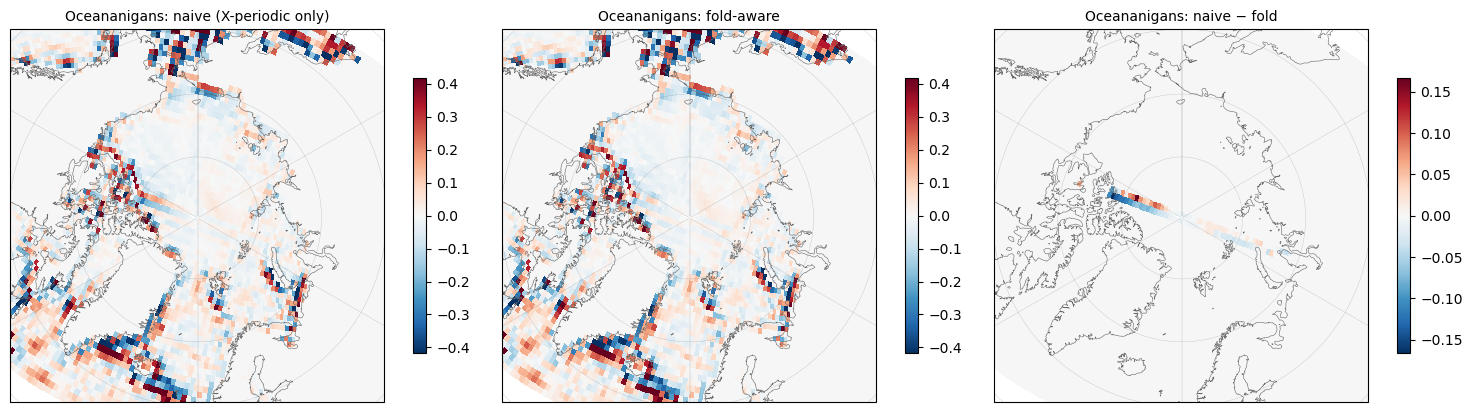

Oceananigans: max|naive - fold|  at seam = 0.2182;  below seam = 0


In [3]:
o = xr.open_dataset("oceananigans_tripolar.nc")
ny, nx = o["tracer"].shape
oc = dict(x_c=np.arange(nx), x_f=np.arange(nx), y_c=np.arange(ny), y_f=np.arange(ny))
u = o["u"].transpose("y_c", "x_f").assign_coords(x_f=oc["x_f"], y_c=oc["y_c"])
v = o["v"].transpose("y_f", "x_c").assign_coords(x_c=oc["x_c"], y_f=oc["y_f"])

zN, zF = naive_and_fold_vorticity(
    xr.Dataset(coords=oc),
    {"X": {"center": "x_c", "right": "x_f"}, "Y": {"center": "y_c", "right": "y_f"}},
    u, v, fold_pivot="u")
lon = o["lon_ff"].transpose("y_f", "x_f").values
lat = o["lat_ff"].transpose("y_f", "x_f").values
show_fold_effect(zN.transpose("y_f", "x_f"), zF.transpose("y_f", "x_f"),
                 lon, lat, "Oceananigans", latmin=60)

## NEMO eORCA1 (IPSL-CM6A-LR, `"corner"` pivot)

Real CMIP6 surface currents read anonymously from the Pangeo cloud. CMIP6 masks
the redundant northern row, so we drop it before folding. `uo` is the U-point,
`vo` the V-point; we use the tracer longitudes/latitudes (`nav_lon`/`nav_lat`)
for the polar view.

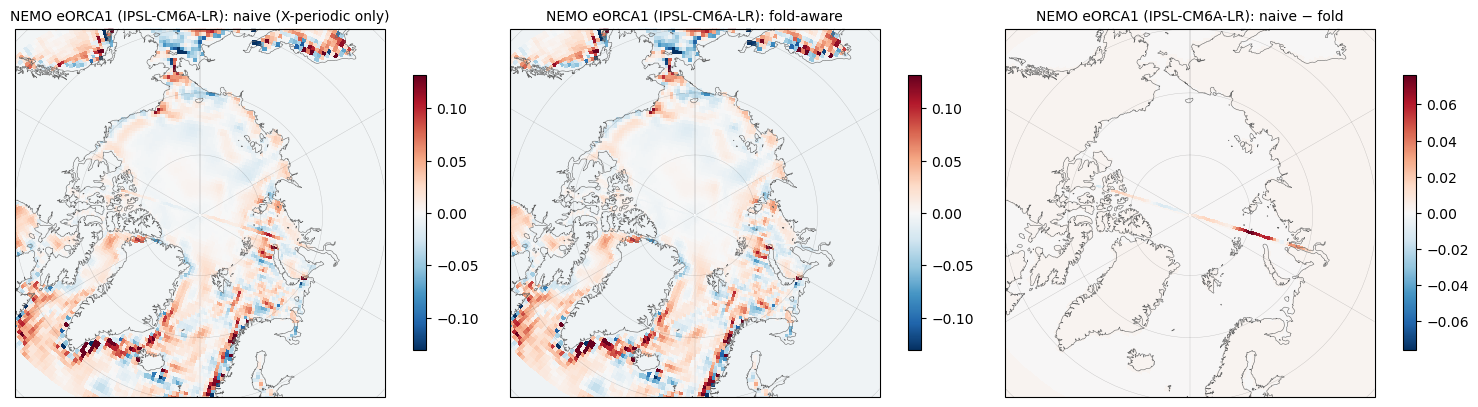

NEMO eORCA1 (IPSL-CM6A-LR): max|naive - fold|  at seam = 0.07767;  below seam = 0


In [4]:
base = ("gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/historical/"
        "r1i1p1f1/Omon/{var}/gn/v20180803/")
so = {"storage_options": {"token": "anon"}}


def _surface(var):
    da = xr.open_dataset(base.format(var=var), engine="zarr", backend_kwargs=so)
    return da[var].isel(time=0, olevel=0)


uo = _surface("uo").isel(y=slice(0, -1))    # drop the masked northern fold row
vo = _surface("vo").isel(y=slice(0, -1))
lon = _surface("uo")["nav_lon"].isel(y=slice(0, -1)).values
lat = _surface("uo")["nav_lat"].isel(y=slice(0, -1)).values
ny, nx = uo.shape
nc = dict(x_c=np.arange(nx), x_f=np.arange(nx), y_c=np.arange(ny), y_f=np.arange(ny))
u = xr.DataArray(uo.values, dims=["y_c", "x_f"]).assign_coords(x_f=nc["x_f"], y_c=nc["y_c"])
v = xr.DataArray(vo.values, dims=["y_f", "x_c"]).assign_coords(x_c=nc["x_c"], y_f=nc["y_f"])

zN, zF = naive_and_fold_vorticity(
    xr.Dataset(coords=nc),
    {"X": {"center": "x_c", "right": "x_f"}, "Y": {"center": "y_c", "right": "y_f"}},
    u, v, fold_pivot="corner")
show_fold_effect(zN.transpose("y_f", "x_f"), zF.transpose("y_f", "x_f"),
                 lon, lat, "NEMO eORCA1 (IPSL-CM6A-LR)", latmin=60)

## MOM6 (GFDL-CM4, `"corner"` pivot)

Real CMIP6 surface currents from **GFDL-CM4** (MOM6 on a tripolar grid), read
anonymously from the Pangeo cloud — exactly as for NEMO above, but with MOM6's
`"corner"` fold pivot. (Surface velocities `uo`/`vo` are the physically correct
fields here, not the vertically-integrated mass transports.)

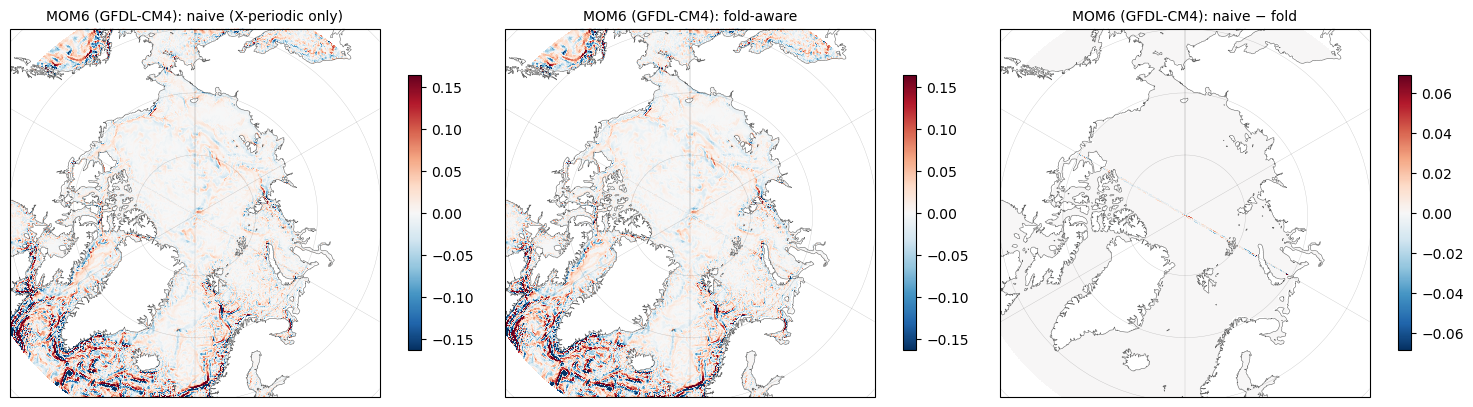

MOM6 (GFDL-CM4): max|naive - fold|  at seam = 0.1308;  below seam = 0


In [5]:
gfdl = ("gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/historical/"
        "r1i1p1f1/Omon/{var}/gn/v20180701/")


def _gfdl_surface(var):
    da = xr.open_dataset(gfdl.format(var=var), engine="zarr", backend_kwargs=so)
    return da[var].isel(time=0, lev=0)


uo = _gfdl_surface("uo").isel(y=slice(0, -1))    # drop the redundant northern row
vo = _gfdl_surface("vo").isel(y=slice(0, -1))
lon = _gfdl_surface("uo")["lon"].isel(y=slice(0, -1)).values
lat = _gfdl_surface("uo")["lat"].isel(y=slice(0, -1)).values
ny, nx = uo.shape
mc = dict(x_c=np.arange(nx), x_f=np.arange(nx), y_c=np.arange(ny), y_f=np.arange(ny))
u = xr.DataArray(uo.values, dims=["y_c", "x_f"]).assign_coords(x_f=mc["x_f"], y_c=mc["y_c"])
v = xr.DataArray(vo.values, dims=["y_f", "x_c"]).assign_coords(x_c=mc["x_c"], y_f=mc["y_f"])

zN, zF = naive_and_fold_vorticity(
    xr.Dataset(coords=mc),
    {"X": {"center": "x_c", "right": "x_f"}, "Y": {"center": "y_c", "right": "y_f"}},
    u, v, fold_pivot="corner")
show_fold_effect(zN.transpose("y_f", "x_f"), zF.transpose("y_f", "x_f"),
                 lon, lat, "MOM6 (GFDL-CM4)", latmin=60)

## Takeaway

On the polar projection the naive (X-periodic-only) and fold-aware relative
vorticity are visually identical over the cap **except along a single line** —
the fold seam connecting the two poles — where the naive calculation is wrong
because it cannot see the velocity across the pole. The naive-minus-fold panel
isolates that line. xgcm's `boundary={"Y": {"fold": ...}}` mirrors the seam and
sign-flips the folded velocity automatically, giving the physically correct
Arctic vorticity for **all three** tripolar conventions — the same machinery,
with only the pivot (`"corner"` for MOM6/NEMO, `"u"` for Oceananigans) differing.

See the [grid topology](../grid_topology.md) docs for the full fold
specification, and [`03_MOM6.ipynb`](03_MOM6.ipynb) for a single-model walkthrough.